Set up paths for the notebook

In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

result_path = os.getcwd()
within_group_path = os.path.join(result_path, 'within_group')
between_group_path = os.path.join(result_path, 'between_group')


In [7]:
def filter_duplicates(df: pd.DataFrame):
    '''
    Filter dataframe that has symmetric exp_a and exp_b entries to only keep one of them.
    :param: df: DataFrame from .csv file.

    :return: filtered DataFrame.
    '''
    df = df.copy()
    df['pair_id'] = df.apply(lambda x: tuple(sorted([x['exp_a'], x['exp_b']])), axis=1)
    df = df.drop_duplicates(subset='pair_id', keep='first')
    df = df.drop(columns='pair_id')
    return df


In [8]:
def visualize_comparison_boxplot(trial_id: str, metric_column: str):
    """
    Visualize boxplots comparing a specific metric across different groups for a given trial.

    :param: trial_id: The ID of the trial to visualize.
    :param: metric_column: The column name of the metric to compare.

    :return: None
    """
    path_with_trial = os.path.join(within_group_path, f'trial_{trial_id}')
    group_files = [f for f in os.listdir(path_with_trial) if f.endswith(".csv")]
    
    graph_folder = os.path.join(result_path, 'graph')
    trial_folder = os.path.join(graph_folder, f'trial_{trial_id}')
    boxplot_folder = os.path.join(trial_folder, 'boxplot')
    os.makedirs(boxplot_folder, exist_ok=True)
    
    all_data = []
    group_names = []
    
    for group_file in group_files:
        group_path = os.path.join(path_with_trial, group_file)
        df = pd.read_csv(group_path)
        df_filtered = filter_duplicates(df)

        if metric_column in df_filtered.columns:
            group_name = group_file.replace(".csv", "")
            all_data.extend(df_filtered[metric_column].dropna().tolist())
            group_names.extend([group_name] * len(df_filtered[metric_column].dropna()))
    
    if all_data:
        comparison_df = pd.DataFrame({
            'Group': group_names,
            metric_column: all_data
        })
        
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=comparison_df, x='Group', y=metric_column)
        plt.title(f'Comparison of {metric_column} across Groups - Trial {trial_id}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        filename = f'trial_{trial_id}_{metric_column}_boxplot.png'
        filepath = os.path.join(boxplot_folder, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot saved: {filepath}")
        
        plt.show()
    else:
        print(f"No data found for metric '{metric_column}' in trial {trial_id}")


In [9]:
def visualize_comparison_histogram(trial_id: str, metric_column: str):
    """
    Visualize histograms comparing a specific metric across different groups for a given trial.

    :param: trial_id: The ID of the trial to visualize.
    :param: metric_column: The column name of the metric to compare.

    :return: None
    """
    path_with_trial = os.path.join(within_group_path, f'trial_{trial_id}')
    group_files = [f for f in os.listdir(path_with_trial) if f.endswith(".csv")]
    
    graph_folder = os.path.join(result_path, 'graph')
    trial_folder = os.path.join(graph_folder, f'trial_{trial_id}')
    histogram_folder = os.path.join(trial_folder, 'histogram')
    os.makedirs(histogram_folder, exist_ok=True)
    
    all_data = []
    group_names = []
    
    for group_file in group_files:
        group_path = os.path.join(path_with_trial, group_file)
        df = pd.read_csv(group_path)
        df_filtered = filter_duplicates(df)

        if metric_column in df_filtered.columns:
            group_name = group_file.replace(".csv", "").replace("_results", "")  # 清理组名
            all_data.extend(df_filtered[metric_column].dropna().tolist())
            group_names.extend([group_name] * len(df_filtered[metric_column].dropna()))
    
    if all_data:
        comparison_df = pd.DataFrame({
            'Group': group_names,
            metric_column: all_data
        })
        
        plt.figure(figsize=(14, 8))

        custom_colors = {
            'Java_none': '#E74C3C',
            'Java_low': '#3498DB',  
            'Java_medium': '#F39C12',
            'Java_high': '#2ECC71',
        }

        unique_groups = comparison_df['Group'].unique()
        palette_colors = [custom_colors.get(group, '#95A5A6') for group in unique_groups]

        sns.histplot(data=comparison_df, x=metric_column, hue='Group', 
                    bins=20, alpha=0.5, kde=True, palette=palette_colors,
                    stat='density')
        
        legend_labels = []
        for group in comparison_df['Group'].unique():
            group_data = comparison_df[comparison_df['Group'] == group][metric_column]
            mean_val = group_data.mean()
            std_val = group_data.std()
            count = len(group_data)
            legend_labels.append(f'{group} (n={count}, μ={mean_val:.3f}, σ={std_val:.3f})')
        
        plt.title(f'Distribution of {metric_column} across Groups - Trial {trial_id}', 
                 fontsize=14, fontweight='bold')
        plt.xlabel(f'{metric_column} Value', fontsize=12, fontweight='bold')
        plt.ylabel('Density', fontsize=12, fontweight='bold')
        
        plt.legend(labels=legend_labels, title='Groups', 
                  title_fontsize=12, fontsize=10, loc='upper right')
        
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        filename = f'trial_{trial_id}_{metric_column}_histogram.png'
        filepath = os.path.join(histogram_folder, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot saved: {filepath}")
        
        plt.show()
    else:
        print(f"No data found for metric '{metric_column}' in trial {trial_id}")

def visualize_comparison_histogram_subplots(trial_id: str, metric_column: str):
    """
    Visualize histograms as subplots for each group separately.

    :param: trial_id: The ID of the trial to visualize.
    :param: metric_column: The column name of the metric to compare.

    :return: None
    """
    path_with_trial = os.path.join(within_group_path, f'trial_{trial_id}')
    group_files = [f for f in os.listdir(path_with_trial) if f.endswith(".csv")]
    
    graph_folder = os.path.join(result_path, 'graph')
    trial_folder = os.path.join(graph_folder, f'trial_{trial_id}')
    histogram_folder = os.path.join(trial_folder, 'histogram')
    os.makedirs(histogram_folder, exist_ok=True)
    
    group_data = {}
    
    for group_file in group_files:
        group_path = os.path.join(path_with_trial, group_file)
        df = pd.read_csv(group_path)
        df_filtered = filter_duplicates(df)

        if metric_column in df_filtered.columns:
            group_name = group_file.replace(".csv", "").replace("_results", "")  # 清理组名
            group_data[group_name] = df_filtered[metric_column].dropna().tolist()
    
    if group_data:
        n_groups = len(group_data)
        n_cols = min(3, n_groups)
        n_rows = (n_groups + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
        if n_groups == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes
        else:
            axes = axes.flatten()
        
        colors = plt.cm.Set2(np.linspace(0, 1, n_groups))
        
        for i, (group_name, data) in enumerate(group_data.items()):
            if i < len(axes):
                axes[i].hist(data, bins=20, alpha=0.7, edgecolor='black', 
                           color=colors[i], density=True)
                
                mean_val = np.mean(data)
                std_val = np.std(data)
                median_val = np.median(data)
                count = len(data)
                
                axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                              label=f'Mean: {mean_val:.3f}')
                axes[i].axvline(median_val, color='blue', linestyle='-', linewidth=2, 
                              label=f'Median: {median_val:.3f}')
                
                axes[i].set_title(f'{group_name}\n(n={count}, σ={std_val:.3f})', 
                                fontweight='bold')
                axes[i].set_xlabel(f'{metric_column} Value', fontweight='bold')
                axes[i].set_ylabel('Density', fontweight='bold')
                axes[i].legend(fontsize=9)
                axes[i].grid(True, alpha=0.3)
        
        for i in range(len(group_data), len(axes)):
            axes[i].set_visible(False)
        
        plt.suptitle(f'Distribution of {metric_column} by Group - Trial {trial_id}', 
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        
        filename = f'trial_{trial_id}_{metric_column}_histogram_subplots.png'
        filepath = os.path.join(histogram_folder, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot saved: {filepath}")
        
        plt.show()
    else:
        print(f"No data found for metric '{metric_column}' in trial {trial_id}")

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\boxplot\trial_5_Shape_boxplot.png


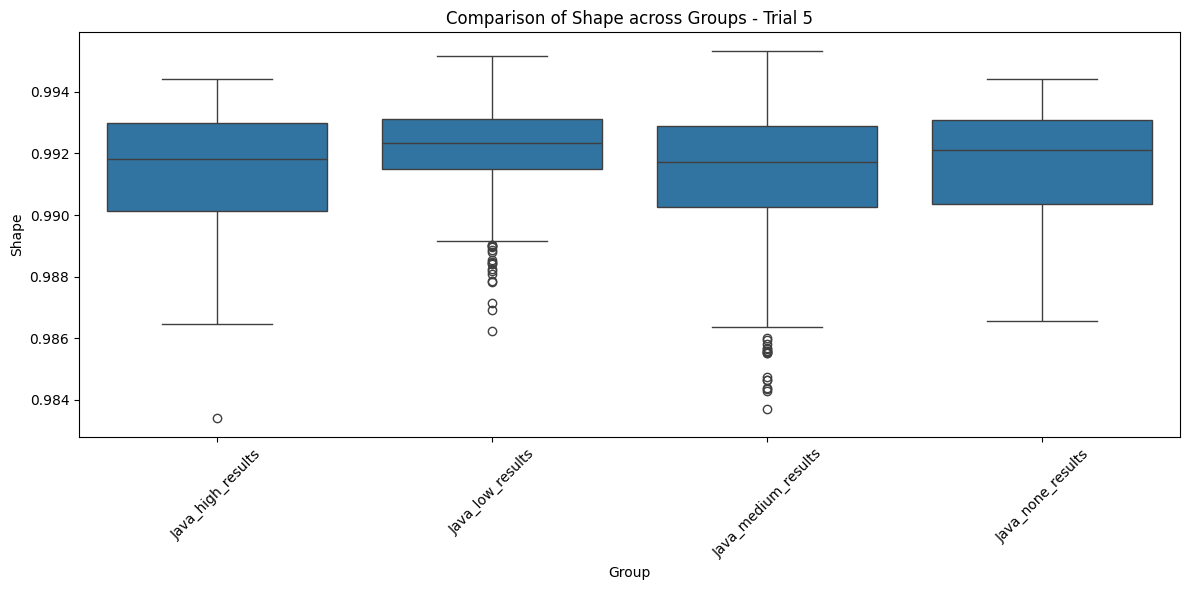

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\histogram\trial_5_Shape_histogram.png


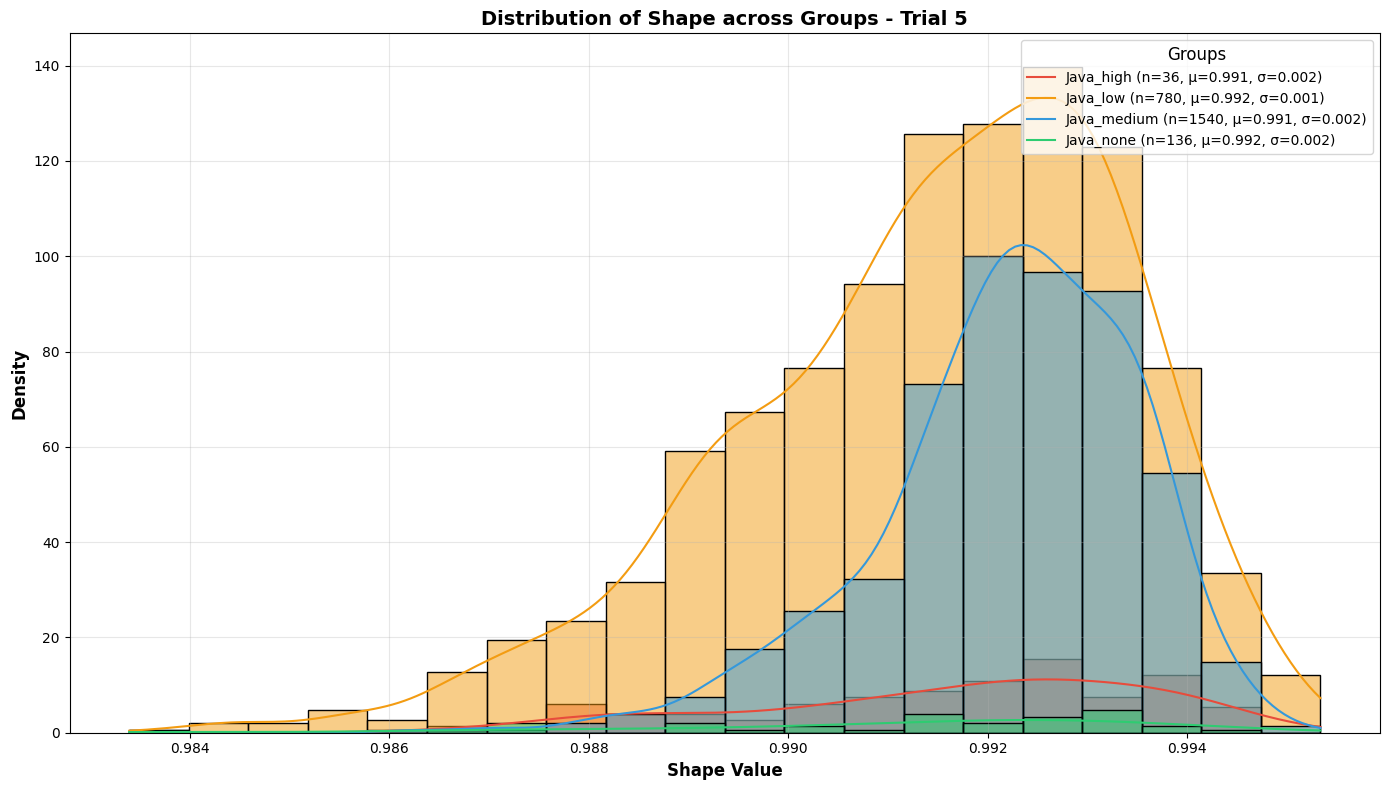

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\histogram\trial_5_Shape_histogram_subplots.png


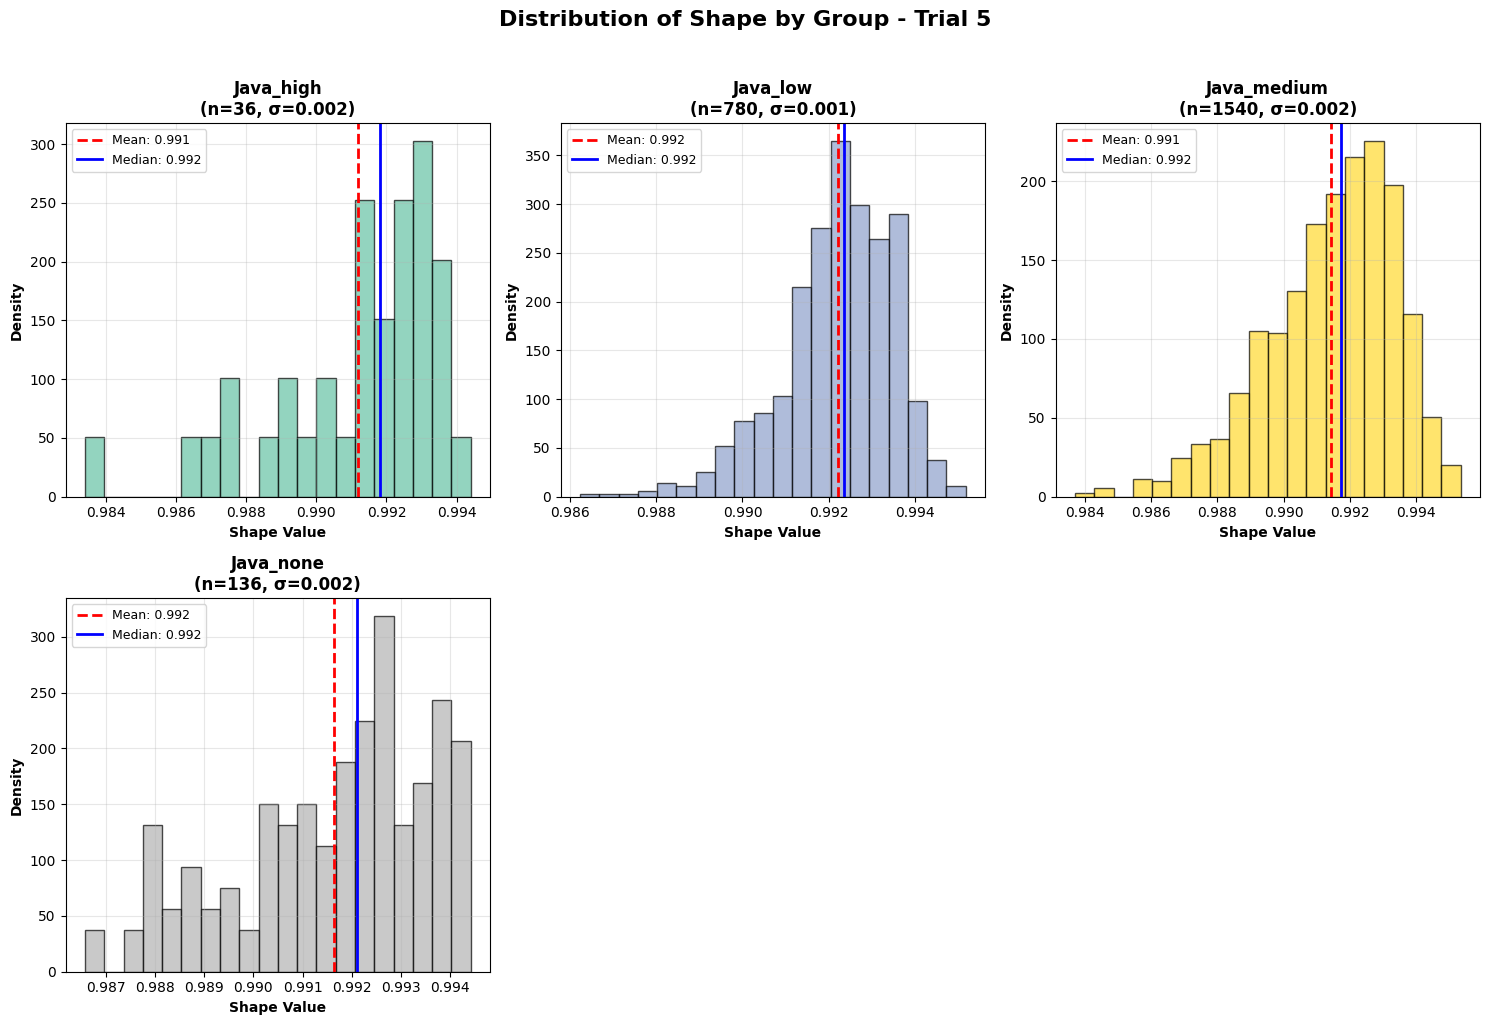

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\boxplot\trial_5_Length_boxplot.png


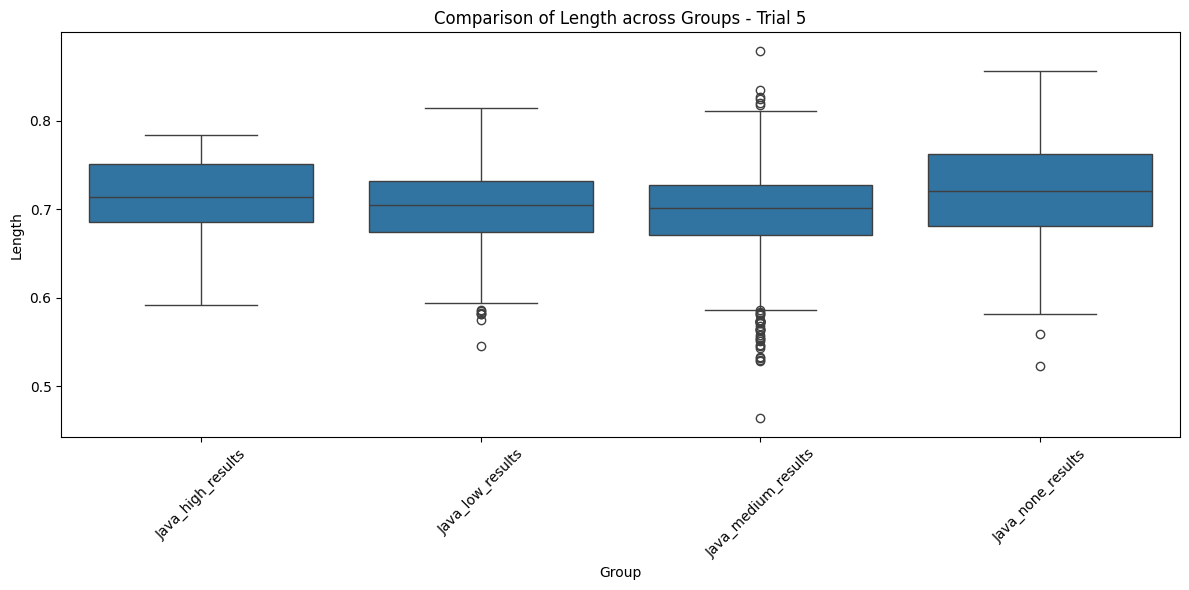

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\histogram\trial_5_Length_histogram.png


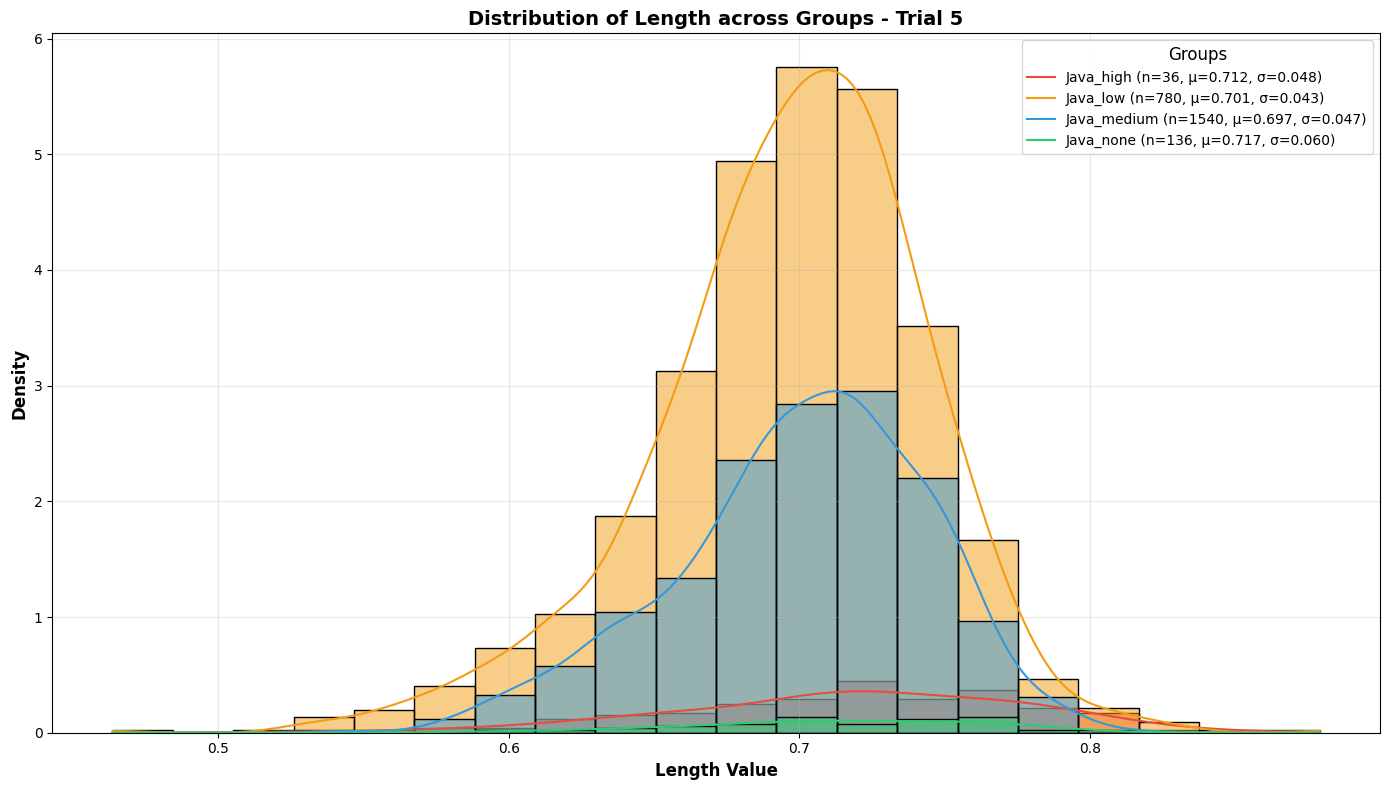

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\histogram\trial_5_Length_histogram_subplots.png


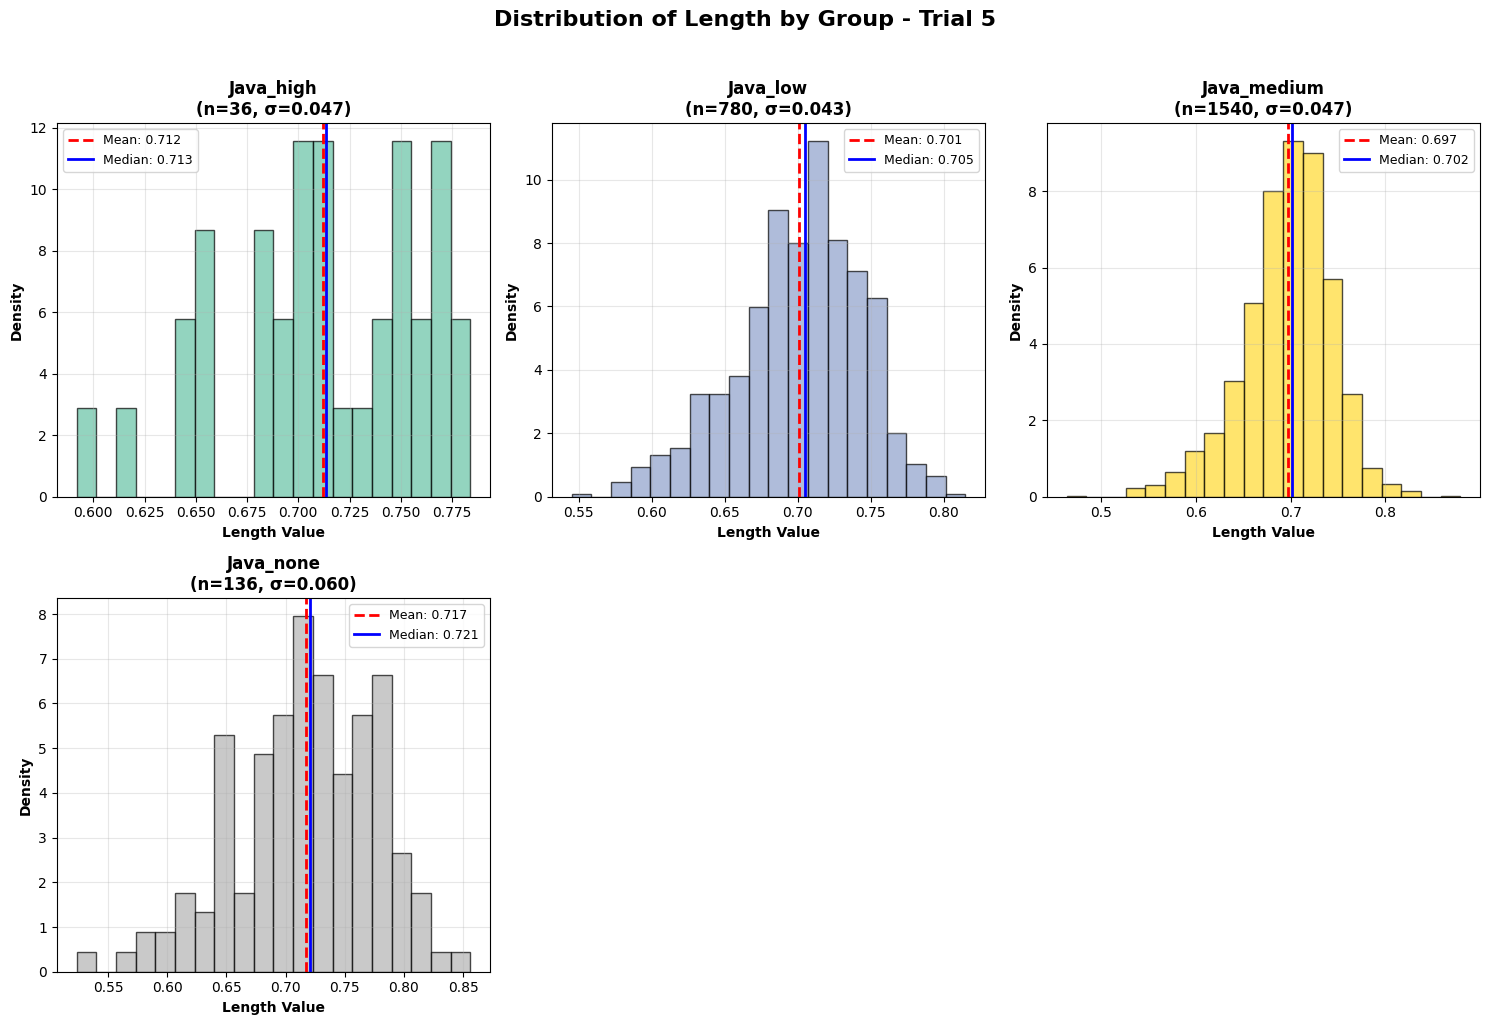

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\boxplot\trial_5_Direction_boxplot.png


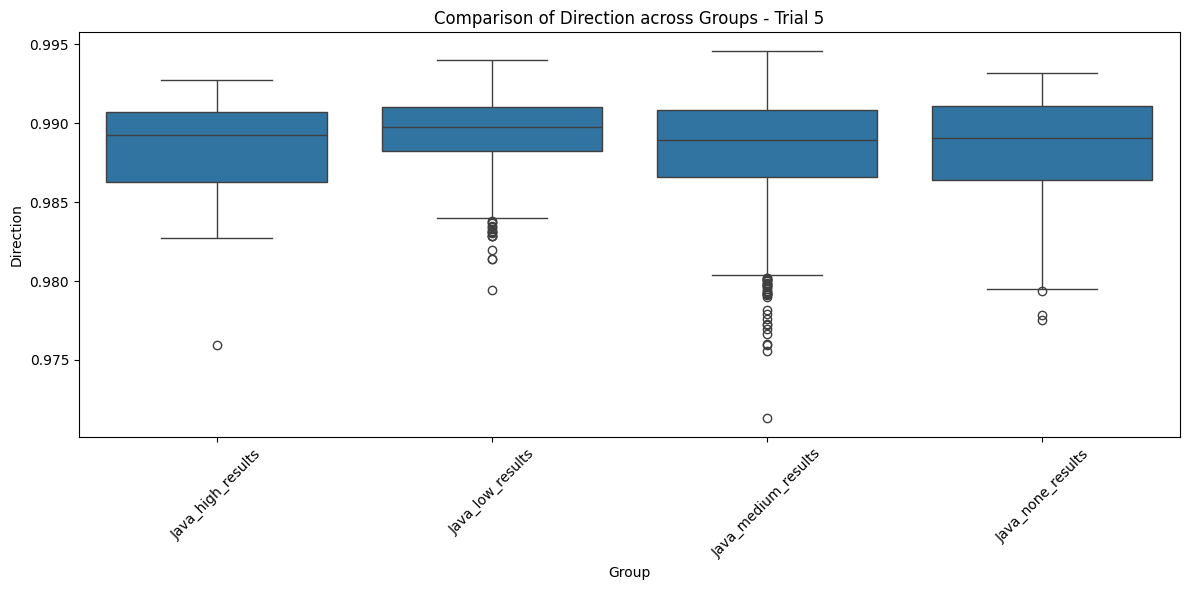

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\histogram\trial_5_Direction_histogram.png


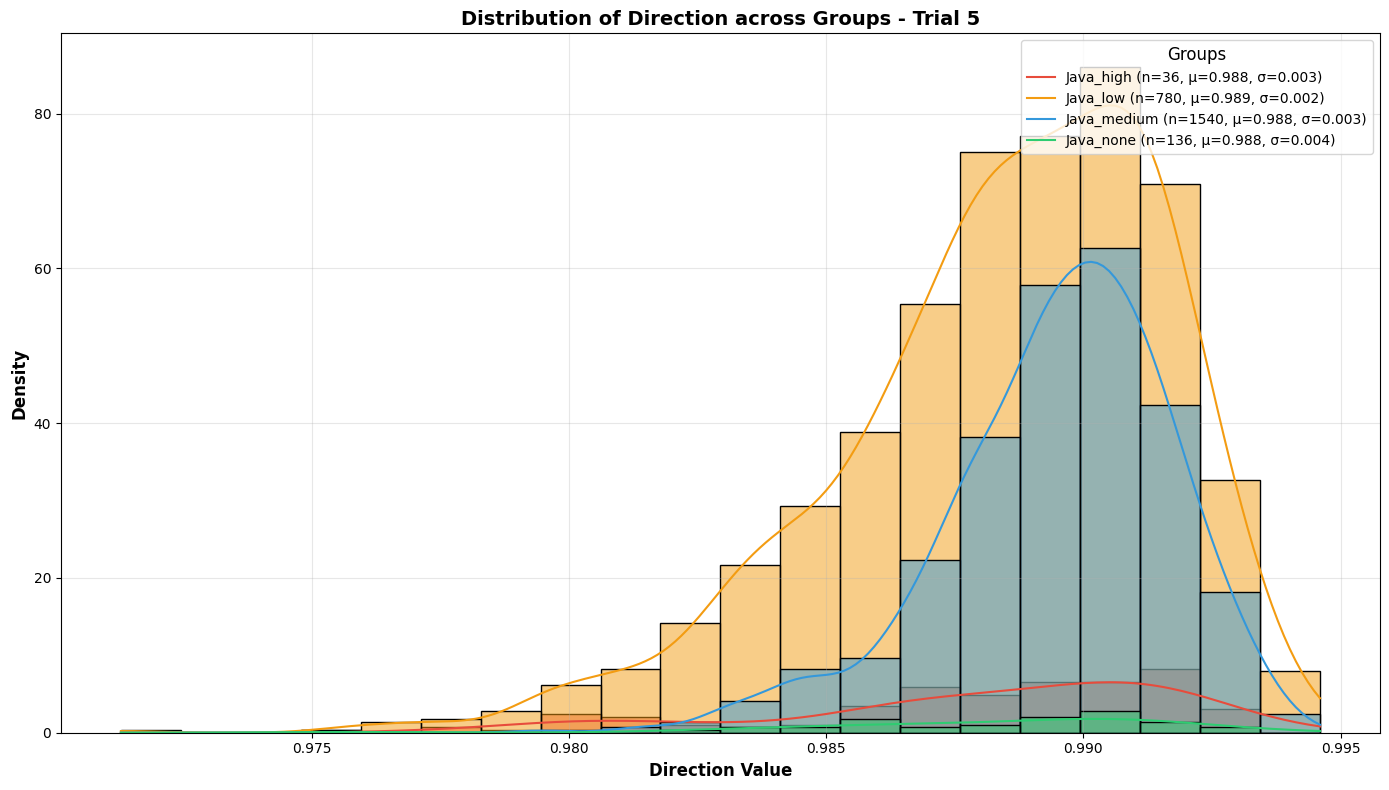

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\histogram\trial_5_Direction_histogram_subplots.png


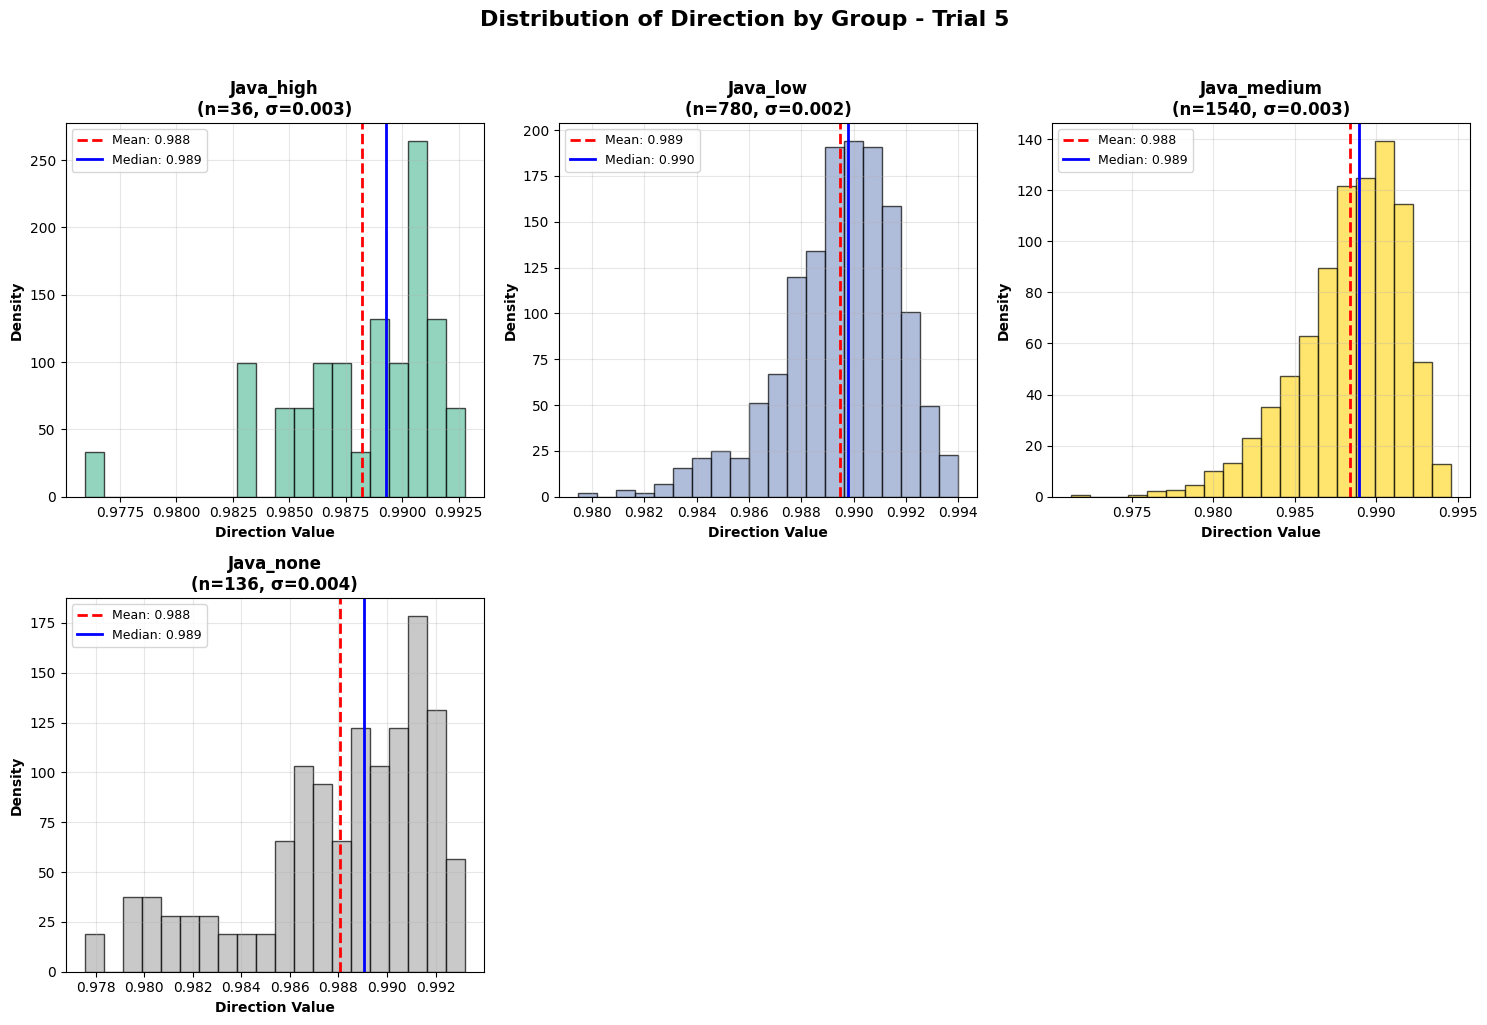

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\boxplot\trial_5_Position_boxplot.png


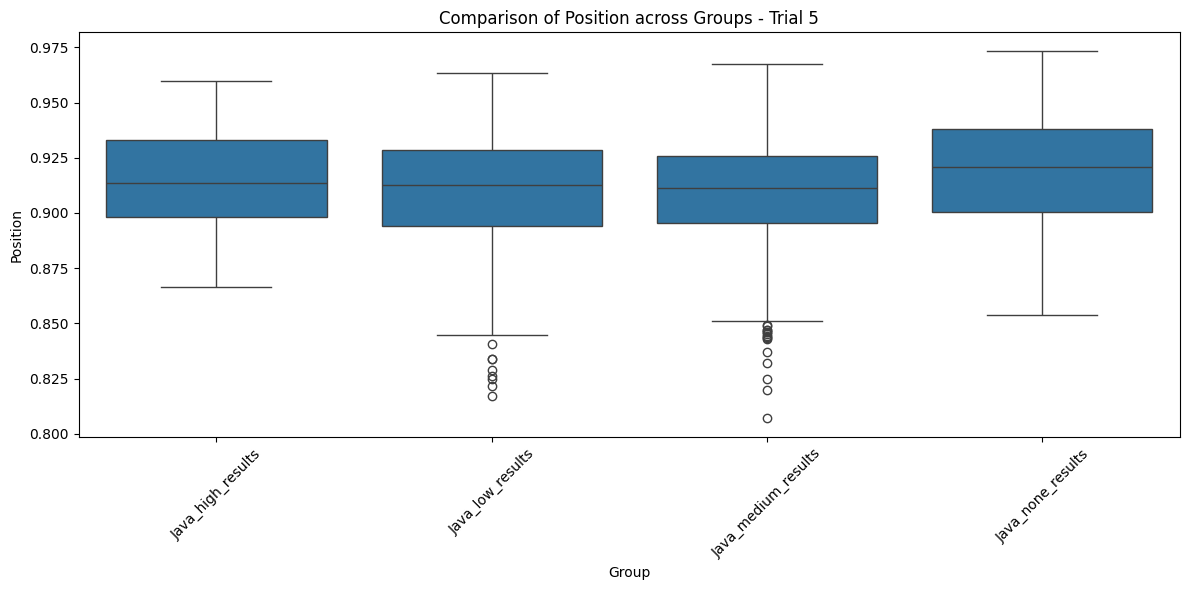

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\histogram\trial_5_Position_histogram.png


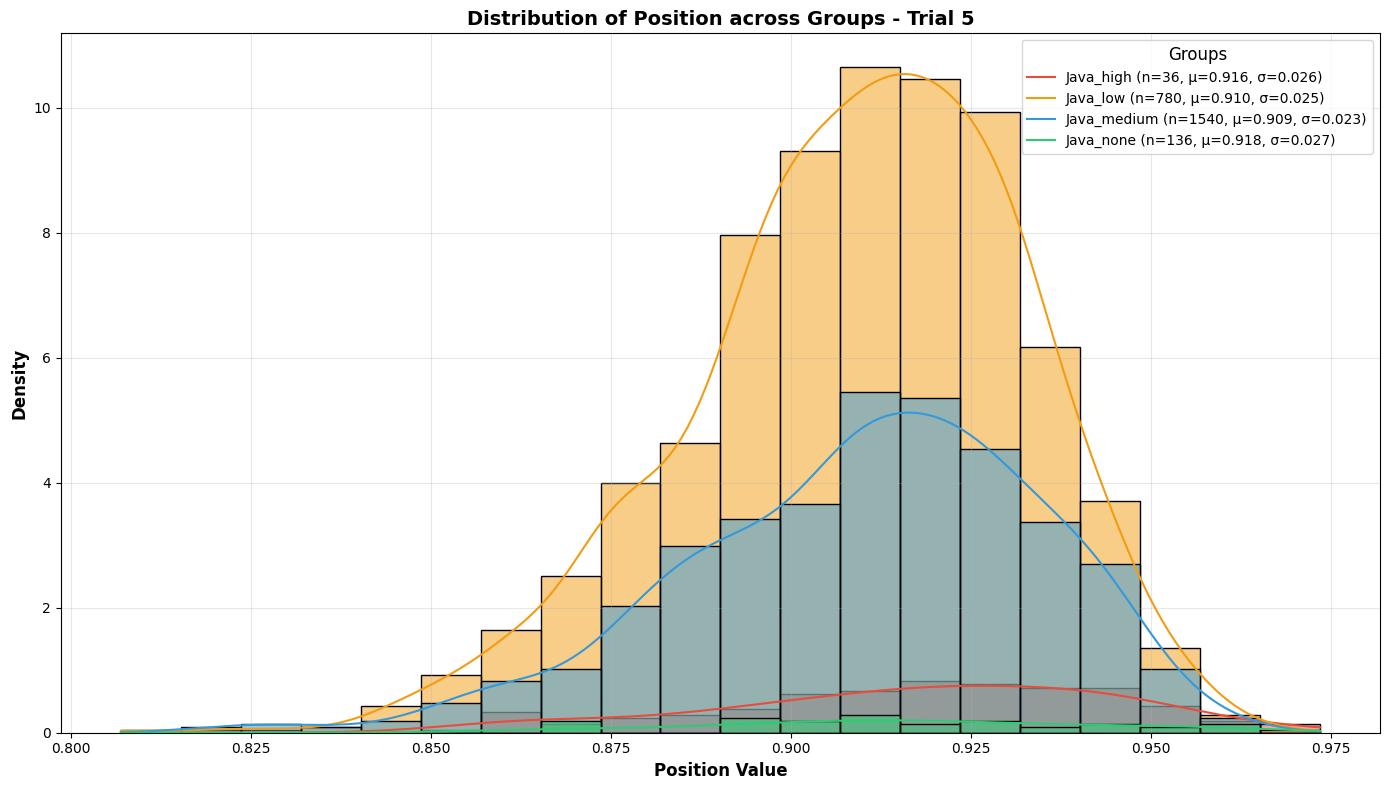

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\histogram\trial_5_Position_histogram_subplots.png


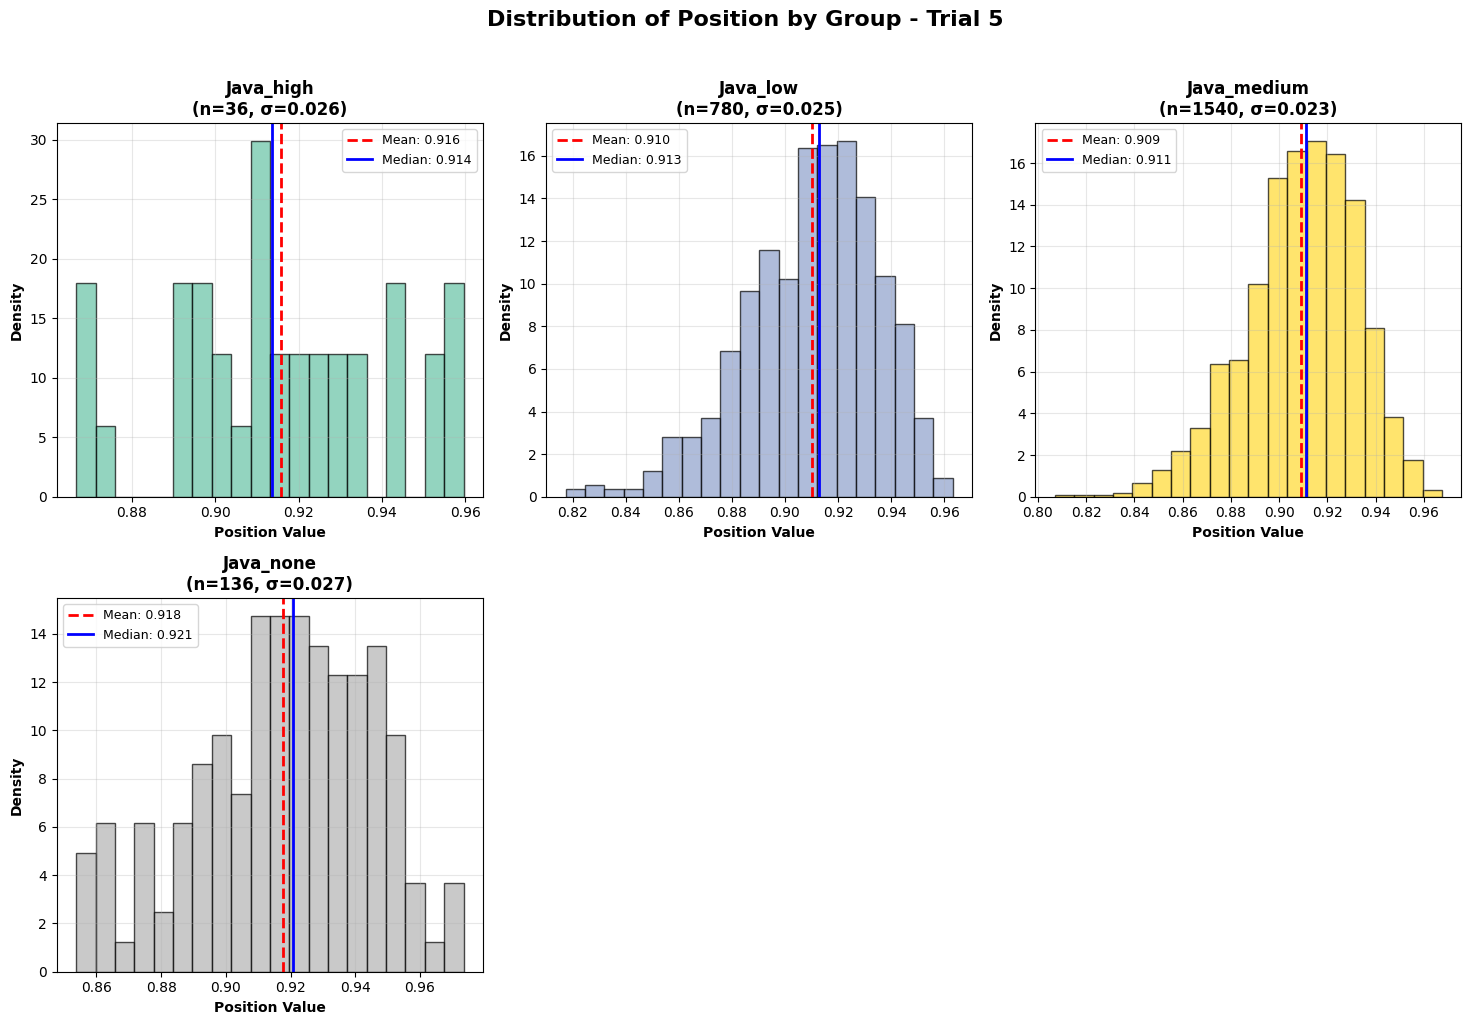

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\boxplot\trial_5_Duration_boxplot.png


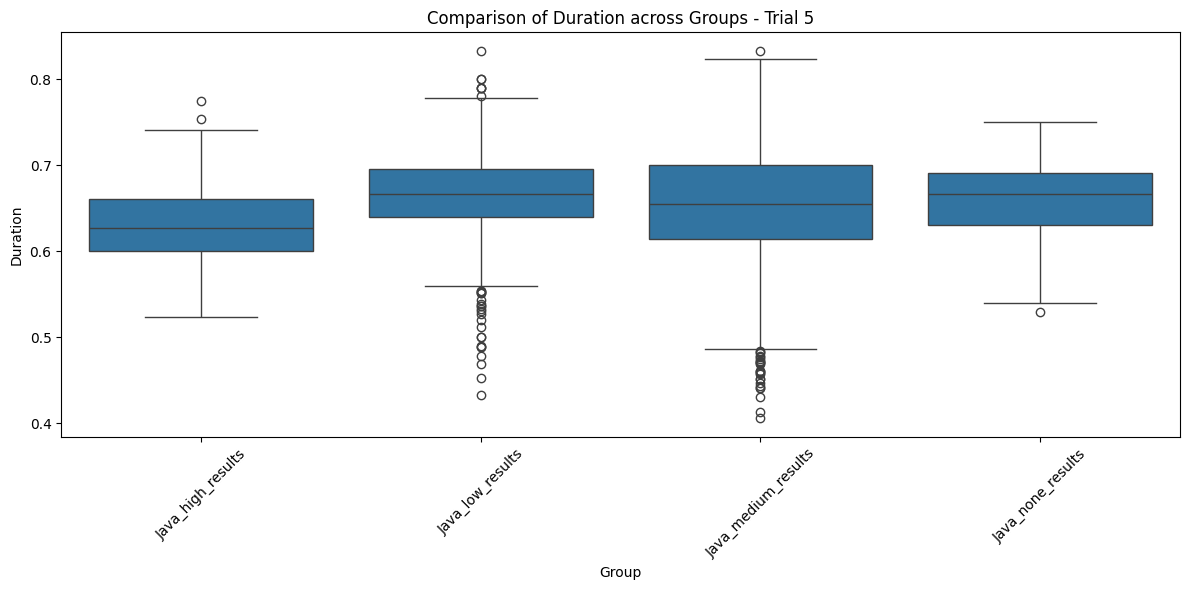

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\histogram\trial_5_Duration_histogram.png


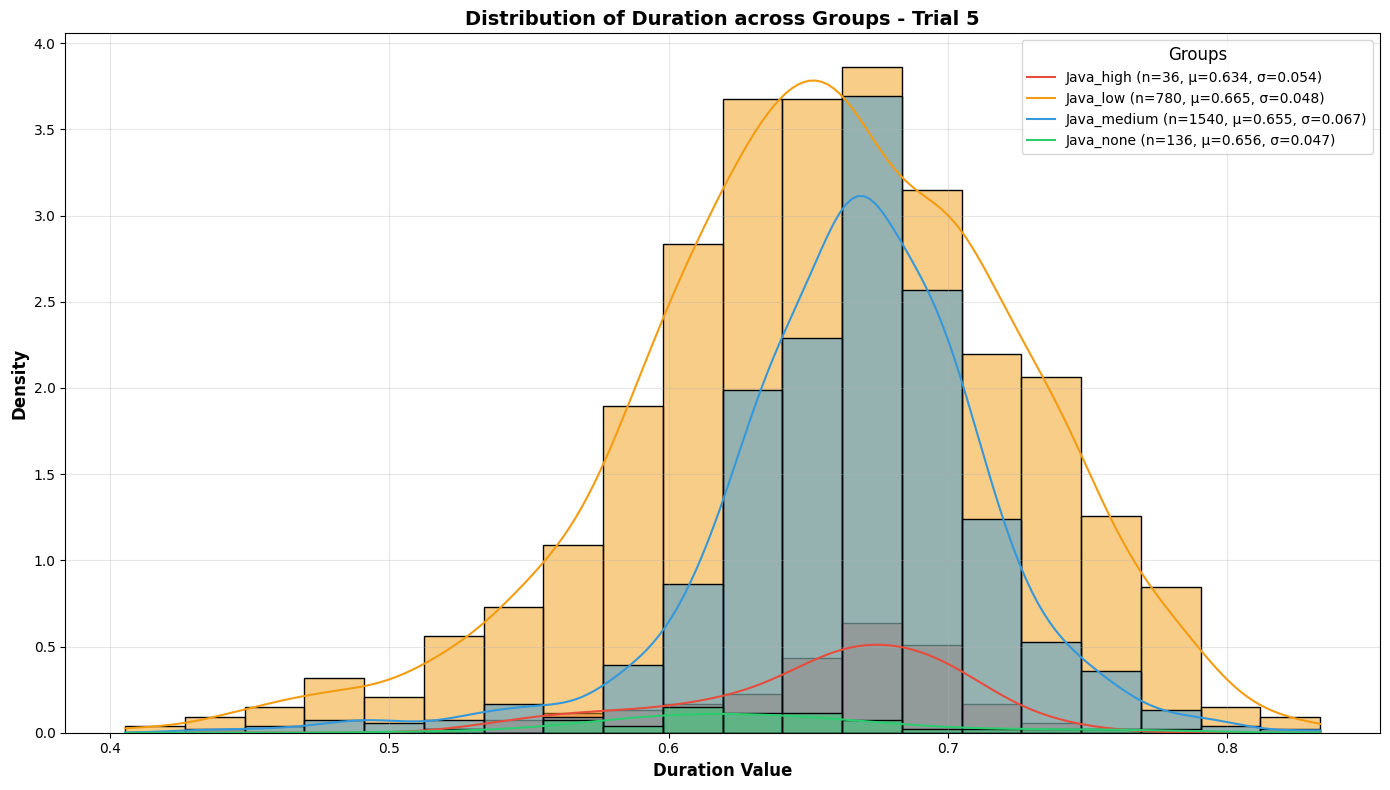

Plot saved: d:\Storage\ETH\Thesis\Code\notebook\EMIP\comparison_results\graph\trial_5\histogram\trial_5_Duration_histogram_subplots.png


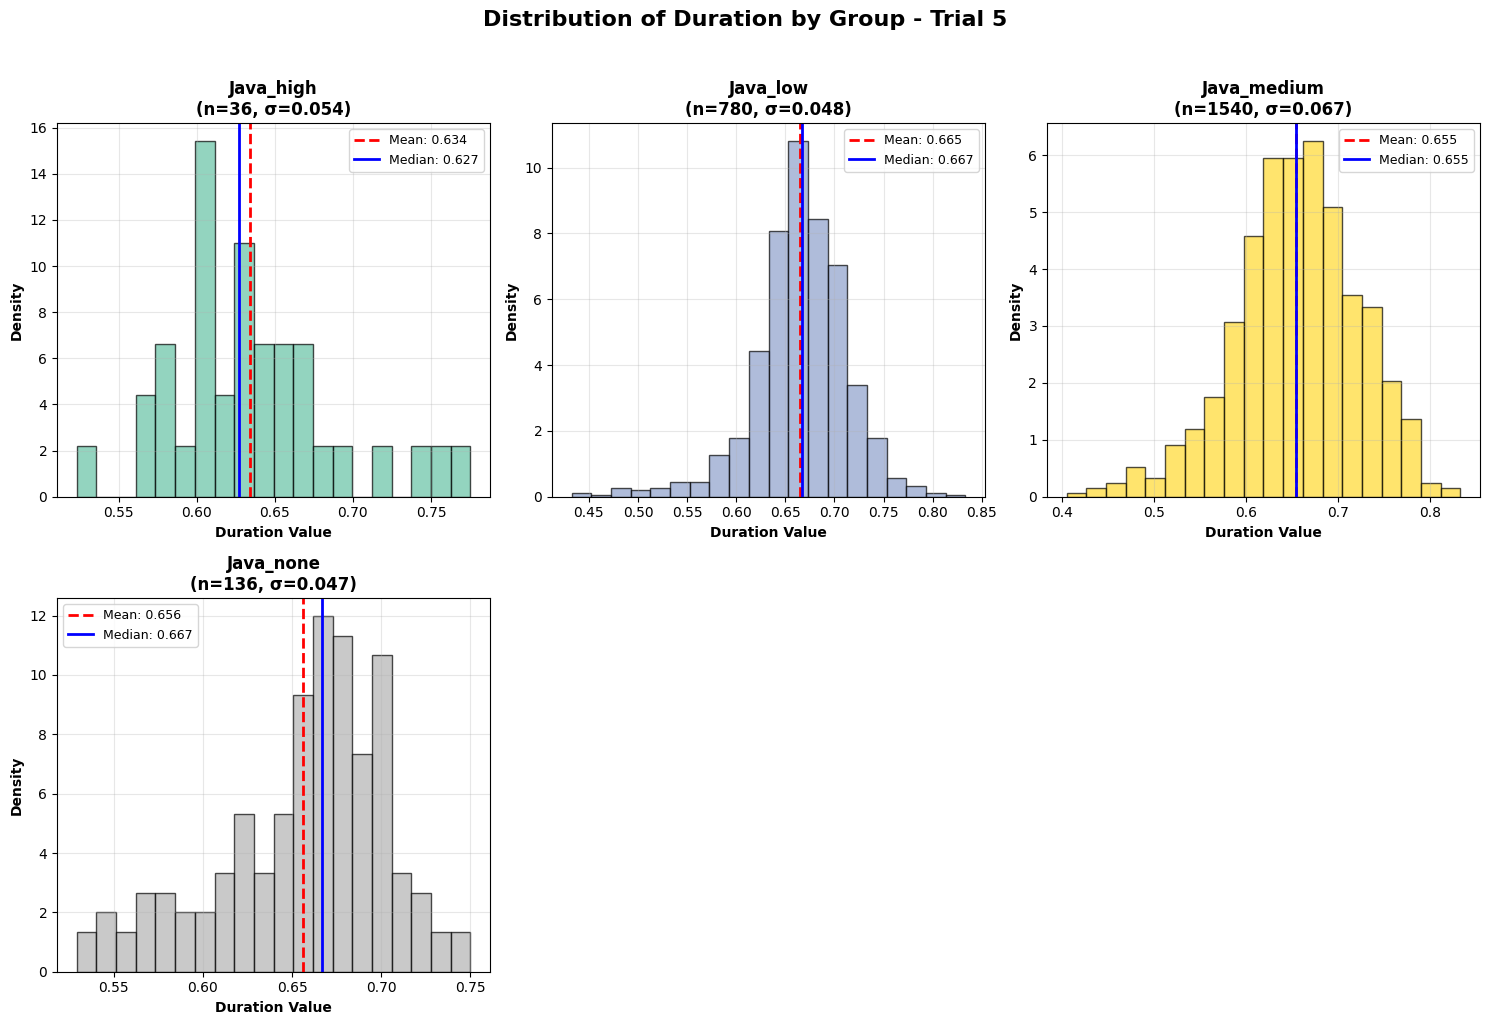

In [10]:
metrics = ['Shape', 'Length', 'Direction', 'Position', 'Duration']

for metric in metrics:
    visualize_comparison_boxplot('5', metric)
    visualize_comparison_histogram('5', metric)
    visualize_comparison_histogram_subplots('5', metric)